<a href="https://colab.research.google.com/github/marinaesca12/Simulaci-n-Cadenas-de-Markov/blob/main/MC_PRADO_(MarinaEsca%C3%B1uelaHueso).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicio: simular y visualizar MCs



In [ ]:
# Importamos librerías básicas que utilizaremos

import numpy as np
import matplotlib.pyplot as plt
import math

## 1. Simular la trayectoria de una MC

Vamos a definir una función que nos permita generar trayectorias de una MC dada. Primero la definiremos de la manera más sencilla, usando dos bucles ```for```. Después veremos que se puede eliminar uno de los bucles para hacerlo más eficiente.

**Importante**: para una MC con $m$ estados, nosotros nos hemos referido a ellos como $\{1,2,\dots,m\}$. Y queremos que esta función que simula trayectorias nos devuelva efectivamente esos posibles estados. Hay al menos dos formas de hacer esto:

1. Hacer toda la implementación usando dicha nomenclatura: $\{1,2,\dots,m\}$.

2. Hacer la implementación usando la siguiente nomenclatura: $\{0,1,\dots,m-1\}$. Es decir, al estado $i$-ésimo pasamos a llamarlo "estado $i-1$" durante la implementación. Y, al final de la función, cuando vayamos a devolver los valores, sumamos $+1$ para que el usuario reciba la verdadera nomenclatura.

La opción 1. parece más sencilla desde el punto de vista lógico. Pero, a la hora de hacer la implementación, puesto que Numpy empieza la indexación en 0 (es decir, el primer elemento de un array de numpy está en la posición 0), el código queda mucho más sencillo y limpio si usamos la opción 2.

In [ ]:
def simular_trayectorias(P, pi_sup_1, n_samples, n_steps):
  """
  Función para simular trayectorias de una MC.

  Input:
  P: matriz de transición de la MC. Numpy array con shape (m, m), donde m es el número de estados.
  pi_sup_1: distribución inicial de la MC. Numpy array con shape (m,).
  n_samples: número de trayectorias a simular. Int.
  n_steps: número de pasos de la simulación. Int.

  Output:
  trayectorias: trayectorias simuladas. Numpy array con shape (n_samples, n_steps).
  """

  # Paso 0: Por comodidad, podemos crear una variable que guarde el valor de m (el número de estados)
  m = P.shape[0]

  # Paso 1: Creamos un array de shape (n_samples, n_steps) con valores arbitrarios. Este array será el que devolvamos, una vez relleno.
  trayectorias = np.zeros((n_samples, n_steps), dtype=int)

  # Paso 2: Simulamos el estado inicial para cada una de las n_samples trayectorias y lo guardamos en la primera columna del array trayectorias.
  trayectorias[:, 0] = np.random.choice(a=m, size=n_samples, p=pi_sup_1)

  # Paso 3: Iterando sobre n_samples y n_steps, rellenamos todo el array "trayectorias".
  for step in range(1, n_steps):
        for sample in range(n_samples):
            # Miramos en qué estado i estamos en el tiempo t-1
            estado_i = trayectorias[sample, step - 1]

            # Simulamos el paso t usando las probabilidades de transición de la fila i
            trayectorias[sample, step] = np.random.choice(a=m, p=P[estado_i, :])

  return trayectorias+1


A continuación vamos a hacer una versión más eficiente de esta función, eliminando uno de los bucles ```for``` (concretamente, el que recorre ```n_samples```). El otro bucle, el que recorre ```n_steps```, no se puede eliminar porque la construcción de la cadena es un proceso inherentemente iterativo. Pero la dimensión sobre ```n_samples``` sí que es conceptualmente paralelizable.

In [ ]:
def simular_trayectorias_effic(P, pi_sup_1, n_samples, n_steps):
  """
  Función para simular trayectorias de una MC.

  Input:
  P: matriz de transición de la MC. Numpy array con shape (m, m), donde m es el número de estados.
  pi_sup_1: distribución inicial de la MC. Numpy array con shape (m,).
  n_samples: número de trayectorias a simular. Int.
  n_steps: número de pasos de la simulación. Int.

  Output:
  trayectorias: trayectorias simuladas. Numpy array con shape (n_samples, n_steps).
  """

  # Paso 0: Por comodidad, podemos crear una variable que guarde el valor de m (el número de estados)
  m = P.shape[0]

  # Paso 1: Creamos un array de shape (n_samples, n_steps) con valores arbitrarios. Este array será el que devolvamos, una vez relleno.
  trayectorias = np.zeros((n_samples, n_steps), dtype=int)

  # Paso 2: Simulamos el estado inicial para cada una de las n_samples trayectorias y lo guardamos en la primera columna del array trayectorias.
  trayectorias[:,0] = np.random.choice(a=m, size=n_samples, p=pi_sup_1)

  # Paso 3: Iterando sobre n_steps, utilizamos numpy (en vez de for) para generar conjuntamente todas las trayectorias.
  for step in range(1, n_steps):
    probs = P[trayectorias[:, step-1], :]   # (n_samples, m)
    probs_acum = np.cumsum(probs, axis=1)   # (n_samples, m)
    probs_acum[:,-1] = np.ones(n_samples)
    u = np.random.rand(n_samples, 1)        # (n_samples, 1)
    trayectorias[:, step] = np.argmax(probs_acum > u, axis=1)

  return trayectorias+1


Una vez implementadas ambas opciones, utilizamos las siguientes celdas para evaluar su eficiencia.

El comando ```%%timeit``` al principio de una celda hace que se ejecute varias veces y se devuelva un resumen de tiempo de ejecución (media y desviación típica sobre diferentes pruebas).


In [ ]:
%%timeit
# Celda para la versión menos eficiente
P = np.array([
    [0.2, 0.3, 0.0, 0.0, 0.5],
    [0.0, 0.1, 0.9, 0.0, 0.0],
    [0.0, 0.0, 0.2, 0.8, 0.0],
    [0.0, 0.7, 0.3, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.0]
])
pi_sup_1 = np.array([0.2, 0.2, 0.2, 0.2, 0.2])
n_samples = 1000
n_steps = 50
trayectorias = simular_trayectorias(P, pi_sup_1, n_samples, n_steps)

1.14 s ± 98.9 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
%%timeit
# Celda para la versión más eficiente
P = np.array([
    [0.2, 0.3, 0.0, 0.0, 0.5],
    [0.0, 0.1, 0.9, 0.0, 0.0],
    [0.0, 0.0, 0.2, 0.8, 0.0],
    [0.0, 0.7, 0.3, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.0]
])
pi_sup_1 = np.array([0.2, 0.2, 0.2, 0.2, 0.2])
n_samples = 1000
n_steps = 50
trayectorias = simular_trayectorias_effic(P, pi_sup_1, n_samples, n_steps)

6.52 ms ± 1.33 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)


Por último en esta sección, utilizamos alguna de las funciones anteriores para generar seis trayectorias durante 50 pasos, y hacemos una visualización similar a la diapositiva 24.

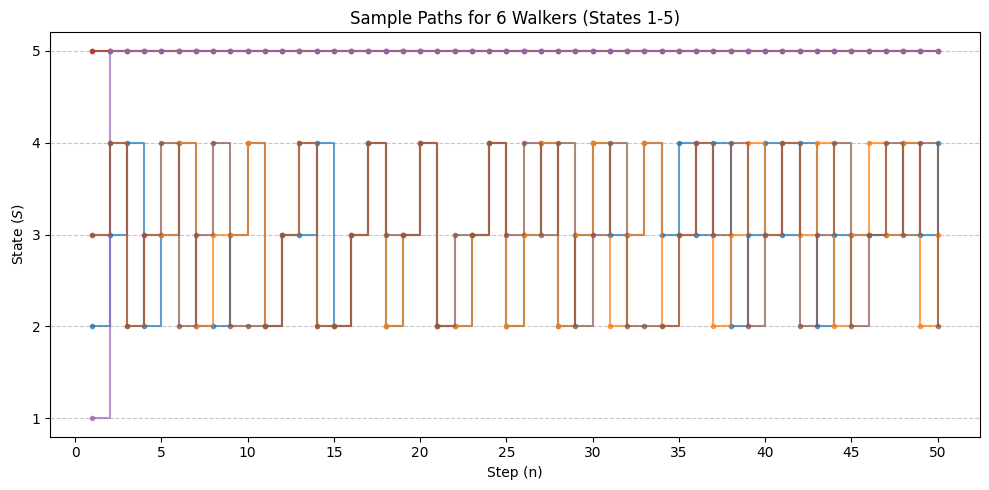

In [ ]:
# COMPLETAR: haz una visualización similar a la diapositiva 24.

P = np.array([
    [0.2, 0.3, 0.0, 0.0, 0.5],
    [0.0, 0.1, 0.9, 0.0, 0.0],
    [0.0, 0.0, 0.2, 0.8, 0.0],
    [0.0, 0.7, 0.3, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.0]
])
pi_sup_1 = np.array([0.2, 0.2, 0.2, 0.2, 0.2])
n_samples = 6
n_steps = 50

trayectorias = simular_trayectorias_effic(P, pi_sup_1, n_samples, n_steps)

plt.figure(figsize=(10, 5))
for i in range(n_samples):
  abscisas_x = np.arange(1, n_steps + 1)
  ordenadas_y = trayectorias[i, :]
  plt.step(abscisas_x, ordenadas_y, where='post', alpha=0.7, marker='o', markersize=3),

m = P.shape[0]
plt.yticks(np.arange(1, m+1))
plt.xticks(np.arange(0, n_steps + 1, 5))
plt.xlabel("Step (n)")
plt.ylabel(r"State ($S$)")
plt.title(f"Sample Paths for {n_samples} Walkers (States 1-5)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 2. Distribución marginal de una MC

Vamos a definir una función que nos permita obtener la distribución marginal de una MC en un instante dado.

In [ ]:
def obtener_marginal(P, pi_sup_1, n):
  """
  Función para calcular la distribución marginal de una MC en cierto instante.

  Input:
  P: matriz de transición de la MC. Numpy array con shape (m, m), donde m es el número de estados.
  pi_sup_1: distribución inicial de la MC. Numpy array con shape (m,).
  n: instante de tiempo en el que se quiere calcular la distribución marginal. Int.

  Output:
  marginal: distribución marginal en el instante n (es decir, lo que hemos llamado pi^{(n)}). Numpy array con shape (m,).
  """

  # Calculamos la matriz P elevada a n-1
  P_power = np.linalg.matrix_power(P, n - 1)

  # Multiplicamos el vector inicial por la matriz resultante
  marginal = pi_sup_1 @ P_power
  return marginal



Utilizamos la función anterior para visualizar empíricamente que la distribución marginal de nuestra MC converge a diferentes distribuciones si empezamos en distribuciones iniciales diferentes. Es decir, reproducimos las imágenes de las diapositivas 61 y 63.

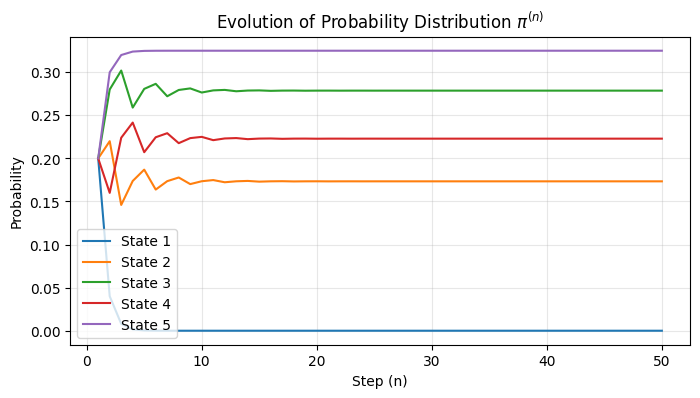

In [ ]:
# Completar para diapositiva 61

P = np.array([
    [0.2, 0.3, 0.0, 0.0, 0.5],
    [0.0, 0.1, 0.9, 0.0, 0.0],
    [0.0, 0.0, 0.2, 0.8, 0.0],
    [0.0, 0.7, 0.3, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.0]
])
pi_sup_1 = np.array([0.2, 0.2, 0.2, 0.2, 0.2])

n_pasos = 50
m = P.shape[0]

marginales = np.zeros((m, n_pasos))
for i in range(n_pasos):
  marginales[:,i] = obtener_marginal(P, pi_sup_1, i+1)

plt.figure(figsize=(8, 4))
for j in range(m):
    plt.plot(np.arange(1, n_pasos+1), marginales[j,:], label=f"State {j+1}")
plt.xlabel("Step (n)")
plt.ylabel("Probability")
plt.title(r"Evolution of Probability Distribution $\pi^{(n)}$")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

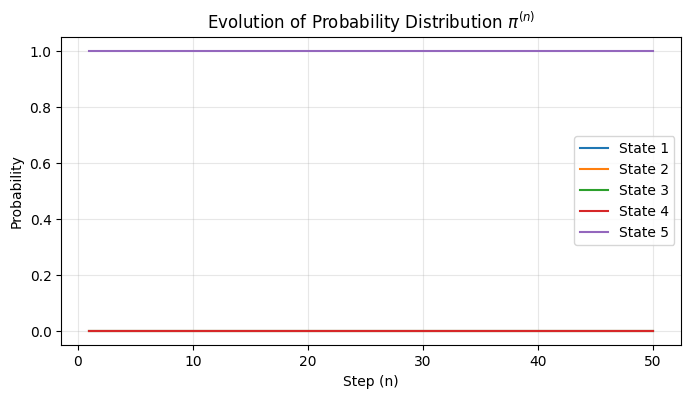

In [ ]:
# Completar para diapositiva 63

P = np.array([
    [0.2, 0.3, 0.0, 0.0, 0.5],
    [0.0, 0.1, 0.9, 0.0, 0.0],
    [0.0, 0.0, 0.2, 0.8, 0.0],
    [0.0, 0.7, 0.3, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.0]
])
pi_sup_1 = np.array([0.0, 0.0, 0.0, 0.0, 1.0])

n_pasos = 50
m = P.shape[0]

marginales = np.zeros((m, n_pasos))
for i in range(n_pasos):
  marginales[:,i] = obtener_marginal(P, pi_sup_1, i + 1)

plt.figure(figsize=(8, 4))
for j in range(m):
    plt.plot(np.arange(1, n_pasos+1), marginales[j,:], label=f"State {j+1}")
plt.xlabel("Step (n)")
plt.ylabel("Probability")
plt.title(r"Evolution of Probability Distribution $\pi^{(n)}$")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 3. Diagrama de transición de estados

Vamos a definir una función para dibujar el diagrama de transición de estados de una MC. Como hemos visto, esta es una de las formas más habituales de visualizar una MC.


In [ ]:
import networkx as nx

def dibujar_diagrama_transicion(P, states):

  # Use DiGraph (Directed Graph)
  G = nx.DiGraph()
  for i in range(len(P)):
      for j in range(len(P)):
          if P[i, j] > 0:
              G.add_edge(states[i], states[j], weight=P[i, j])

  # Define layout
  pos = nx.circular_layout(G)

  # Create the plot
  plt.figure(figsize=(8, 6))

  # Draw nodes and edges
  # 'connectionstyle' curves the edges to prevent overlap on bidirectional paths
  nx.draw(G, pos, with_labels=True, node_color='lightblue',
          node_size=800, arrowsize=20,
          connectionstyle='arc3, rad = 0.1')

  # 2. Add the weights as labels
  edge_labels = nx.get_edge_attributes(G, 'weight')

  # Optional: Format labels to look cleaner (e.g., 0.5 instead of 0.500000)
  formatted_edge_labels = {k: f"{v:g}" for k, v in edge_labels.items()}

  nx.draw_networkx_edge_labels(G, pos, edge_labels=formatted_edge_labels, label_pos=0.2)

  plt.title("State Transition Diagram with Weights")
  plt.show()

Usamos la función anterior para dibujar el diagrama de transición de estados de nuestra MC. Esta es una figura que hemos visto repetidamente (la primera vez en la diapositiva 27).

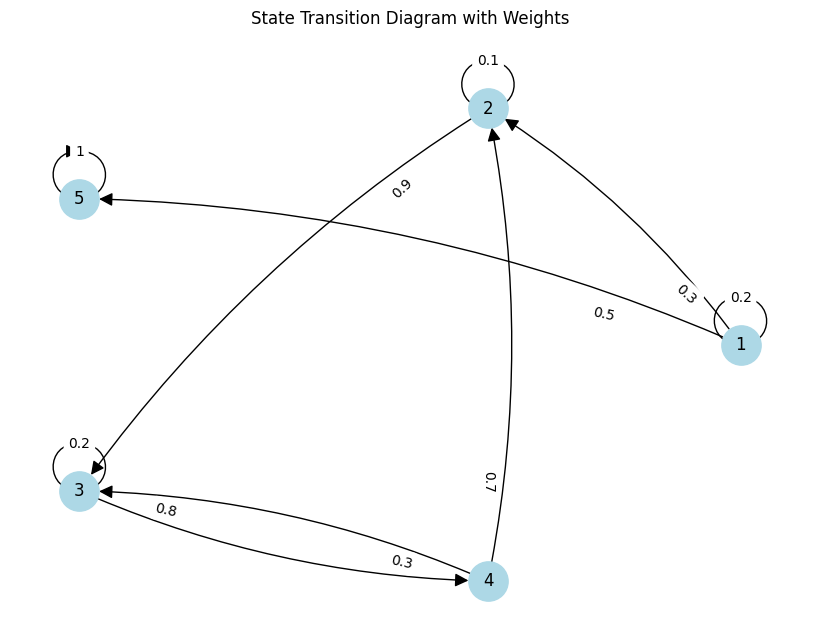

In [ ]:
P = np.array([
    [0.2, 0.3, 0.0, 0.0, 0.5],
    [0.0, 0.1, 0.9, 0.0, 0.0],
    [0.0, 0.0, 0.2, 0.8, 0.0],
    [0.0, 0.7, 0.3, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.0]
])

states = [1,2,3,4,5]
dibujar_diagrama_transicion(P, states)

## 4. Teorema de convergencia de MCs

En esta sección vamos a ilustrar tres ideas que hemos estudiado en el contexto del teorema de convergencia de MCs:

1. Una MC es unicadenal y aperiódica $\iff$ la distribución marginal converge siempre a la misma distribución (independientemente de la distribución inicial).
2. Una MC es aperiódica $\iff$ la distribución marginal converge siempre (aunque el límite puede depender de la distribución inicial).
3. Para MCs en las hipótesis del teorema de convergencia de MCs, la distribución empírica de proporciones del estado $i$-ésimo, lo que habíamos llamado $p_i(n_{samples}, n_{steps})$, converge a la componente $i$-ésima de la distribución estacionaria cuando incrementamos $n_{samples}, n_{steps}$.


Vamos a empezar por definir una función que nos permita visualizar la evolución de la distribución marginal de una MC. Este tipo de gráfica ya la habíamos obtenido en la sección 3, cuando se reprodujeron las diapositivas 61 y 63. No obstante, aquí se encapsula en una función y se hace de manera más eficiente que allí:

In [ ]:
def visualizar_evolucion_marginal(P, pi_sup_1, n_steps):
  """
  Función para visualizar la evolución de la distribución marginal para una MC.

  Input:
  P: matriz de transición de la MC. Numpy array con shape (m, m), donde m es el número de estados.
  pi_sup_1: distribución inicial de la MC. Numpy array con shape (m,).
  n_steps: instante de tiempo hasta el que se quiere visualizar. Int.

  Output:
  La función no devuelve nada por "return", simplemente realiza un gráfico.
  """
  m = P.shape[0]

  # Paso 1: Creamos un array con shape (m, n_steps) y lo rellenamos con las marginales en cada paso.
  marginales = np.zeros((m, n_steps))

  # Asignamos la distribución inicial al primer instante temporal (paso 1, índice 0)
  marginales[:, 0] = pi_sup_1

  # Rellenamos iterativamente multiplicando la marginal anterior por P
  for i in range(1, n_steps):
      marginales[:, i] = marginales[:, i-1] @ P

  # Paso 2: Dibujamos la trayectoria de cada componente de la marginal. Esto puede ser análogo a lo que se hizo al reproducir las diapositivas 61 y 63.
  plt.figure(figsize=(8, 4))
  pasos = np.arange(1, n_steps + 1)

  for j in range(m):
      plt.plot(pasos, marginales[j, :], label=f"State {j+1}")

  plt.xlabel("Step (n)")
  plt.ylabel("Probability")
  plt.title(r"Evolution of Probability Distribution $\pi^{(n)}$")

  # Colocamos la leyenda fuera del gráfico para que no tape las líneas
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
  plt.grid(alpha=0.3)
  plt.tight_layout() # Ajusta los márgenes para que quepa la leyenda
  plt.show()

Considera la siguiente matriz de transición:

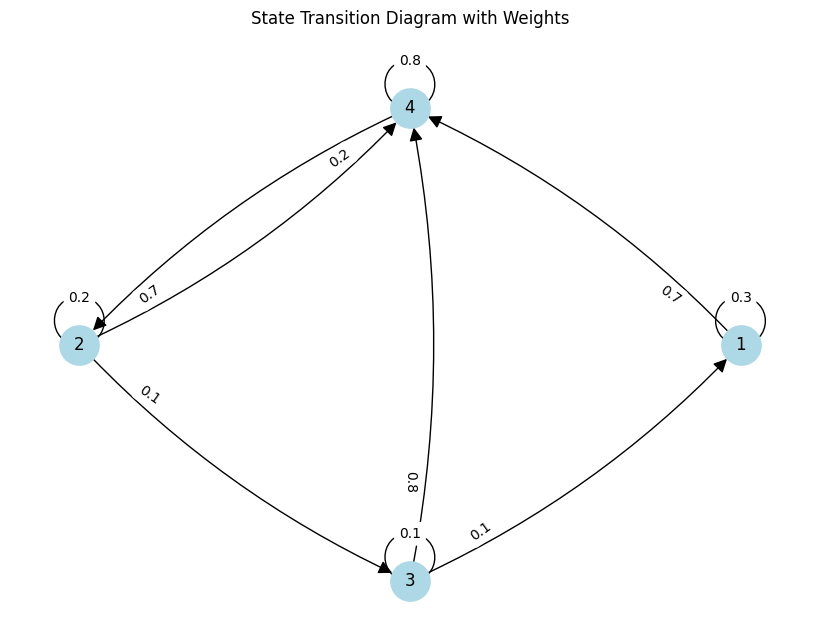

In [ ]:
P = np.array([[0.3,0,0,0.7],
              [0,0.2,0.1,0.7],
              [0.1,0,0.1,0.8],
              [0,0.2,0,0.8]])
dibujar_diagrama_transicion(P, [1,2,3,4])

Comprobamos que una MC con esta matriz de transición es unicadenal (de hecho es irreducible) y aperiódica. Por tanto, está en las condiciones del teorema de convergencia de MCs. Por tanto, la marginal debe converger a una única distribución estacionaria independientemente de la distribución inicial.

En la siguiente celda se obtiene una distribución inicial aleatoria para la MC, y se representan los primeros $50$ pasos de la marginal (también se imprime por pantalla la marginal en el paso 50). Completamos la celda y luego la ejecutamos varias veces para comprobar que siempre se converge al mismo límite.

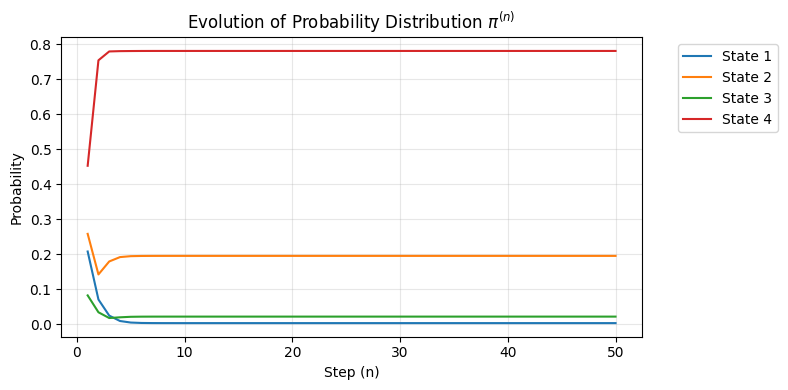

[0.00309598 0.19504644 0.02167183 0.78018576]


In [ ]:
P = np.array([[0.3,0,0,0.7],
              [0,0.2,0.1,0.7],
              [0.1,0,0.1,0.8],
              [0,0.2,0,0.8]])

# Rellenamos las dos siguientes líneas para generar un pi_sup_1 aleatorio válido.
pi_sup_1 = np.random.rand(P.shape[0])
pi_sup_1 = pi_sup_1 / np.sum(pi_sup_1)

visualizar_evolucion_marginal(P, pi_sup_1, 50)
print( obtener_marginal(P, pi_sup_1, 50) )

Cuando hicimos un esbozo de demostración del teorema de convergencia de MCs, recordar diapositivas 89 y 90, vimos que la sucesión de matrices $\{P^n\}_n$ convergía a una matriz en la que todas las filas eran iguales (y coincidían con la única distribución estacionaria).

Vamos a visualizar varios términos de esta sucesión para comprobar empíricamente que esto sucede. Primero vamos a ver cómo podemos representar visualmente una matriz. Una manera habitual es mediante un "heatmap" (mapa de calor). A continuación se realiza dicho gráfico para la MC anterior (mira el gráfico y entiéndelo en particular el código de color):

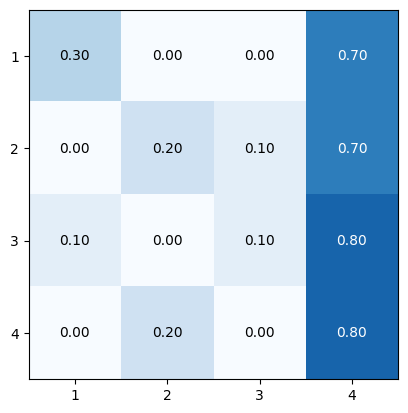

In [ ]:
P = np.array([[0.3,0,0,0.7],
              [0,0.2,0.1,0.7],
              [0.1,0,0.1,0.8],
              [0,0.2,0,0.8]])

# Dibujamos el heatmap
plt.imshow(P, cmap='Blues', vmin=0, vmax=1)

# Añadimos texto con los valores explícitos
m = P.shape[0]
for i in range(m):       # rows
        for j in range(m):   # columns
            value = P[i, j]
            # Dynamically change text color based on cell brightness for readability
            text_color = "white" if value > 0.5 else "black"
            # Add text (note: text coordinates are (column, row) -> (j, i))
            plt.text(j, i, f"{value:.2f}",
                    ha="center", va="center",
                    color=text_color, fontsize=10)

plt.xticks(np.arange(P.shape[0]), labels=1+np.arange(P.shape[0]))
plt.yticks(np.arange(P.shape[0]), labels=1+np.arange(P.shape[0]))

plt.show()

Completamos la siguiente celda para ver la evolución de $\{P^n\}_n$ en tres instantes: $n=1,2,10$. Comprobamos que, efectivamente, esta sucesión parece estabilizarse en una matriz en las que todas las filas son la misma. Y que además coincide con la distribución estacionaria que obtuvimos empíricamente dos celdas más arriba, cuando vimos dónde parecía estabilizarse la marginal de la MC en el paso $50$. (Recuerda que parecía estabilizarse en [0.00309598 0.19504644 0.02167183 0.78018576]).

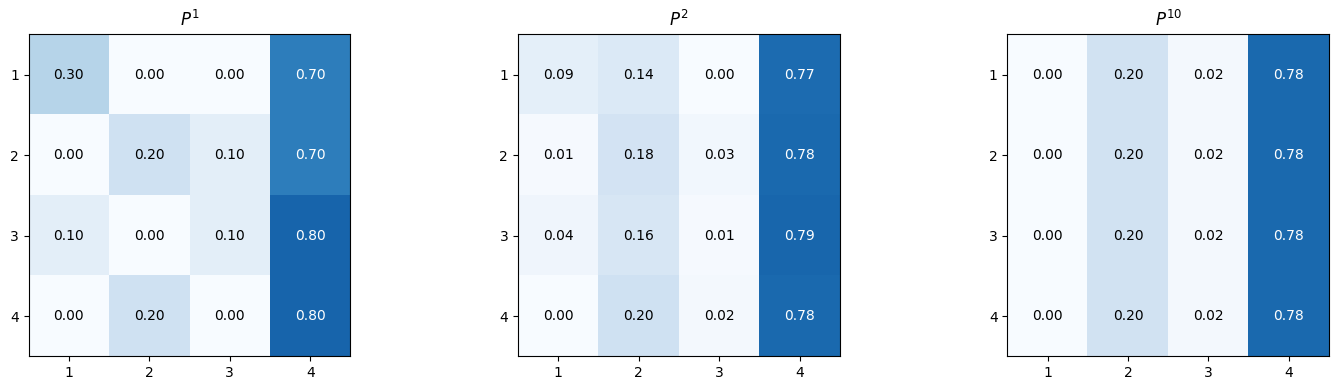

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
steps_to_show = [1, 2, 10]

for ax, n in zip(axes, steps_to_show):

    Pn = np.linalg.matrix_power(P, n)

    im = ax.imshow(Pn, cmap='Blues', vmin=0, vmax=1)
    ax.set_title(f"$P^{{{n}}}$")
    ax.set_xticks(np.arange(P.shape[0]), labels=1+np.arange(P.shape[0]))
    ax.set_yticks(np.arange(P.shape[0]), labels=1+np.arange(P.shape[0]))
    # Loop over data dimensions and create text annotations
    for i in range(Pn.shape[0]):       # rows
        for j in range(Pn.shape[1]):   # columns
            value = Pn[i, j]

            # Dynamically change text color based on cell brightness for readability
            text_color = "white" if value > 0.5 else "black"

            # Add text (note: text coordinates are (column, row) -> (j, i))
            ax.text(j, i, f"{value:.2f}",
                    ha="center", va="center",
                    color=text_color, fontsize=10)

plt.tight_layout()
plt.show()

Vamos ahora a mirar el segundo punto de esta sección. Vamos a mirar una MC que sea periódica. Comprobamos que la siguiente MC es periódica (¿cuál es el periodo de todos sus estados?):

**1. Cálculo del periodo del Estado 1**

El periodo $d(i)$ de un estado se define como el Máximo Común Divisor (MCD) de las longitudes de todos los caminos posibles que empiezan y terminan en ese estado. Vamos a ver en cuántos pasos podemos volver al Estado 1 partiendo del Estado 1:

* Camino corto: 1
$\rightarrow$ 2 $\rightarrow$ 1. Hemos vuelto en 2 pasos.
* Camino largo: 1 $\rightarrow$ 2 $\rightarrow$ 3 $\rightarrow$ 4 $\rightarrow$ 1. Hemos vuelto en 4 pasos.
* Cualquier combinación de estos bucles (por ejemplo, hacer el camino largo y luego el corto) resultará en una cantidad par de pasos (6, 8, 10, etc.).

El conjunto de pasos posibles de retorno es $\{2, 4, 6, 8, \dots\}$. El MCD de este conjunto es 2. Por tanto, $d(1) = 2$.

**2. El periodo del resto de estados**

Si nos fijamos en el diagrama, podemos ir desde cualquier estado a cualquier otro estado. Es decir, hay una única clase de comunicación cerrada, lo que significa que la cadena es irreducible.

En las Cadenas de Markov, la periodicidad es una propiedad de clase. Esto quiere decir que si una cadena es irreducible, todos sus estados comparten el mismo periodo. Por tanto, sin necesidad de hacer los cálculos uno por uno:
* $d(1) = 2$
* $d(2) = 2$
* $d(3) = 2$
* $d(4) = 2$

**3. Conclusión**

Efectivamente, como todos sus estados recurrentes tienen un periodo $d > 1$, podemos afirmar categóricamente que esta Cadena de Markov es periódica con periodo 2. Al ser periódica, ya sabemos que no cumple las hipótesis restrictivas del teorema de convergencia fuerte.

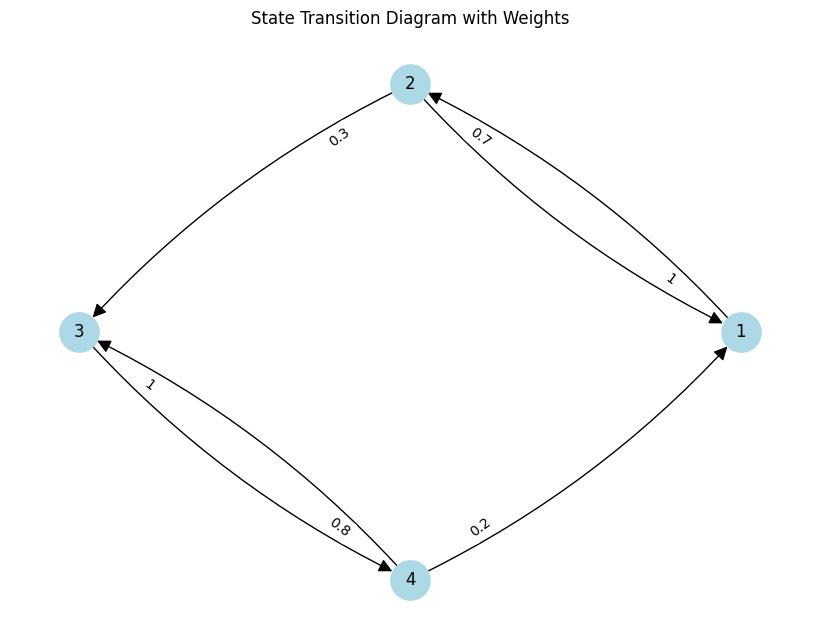

In [ ]:
P = np.array([[0.0,1.0,0.0,0.0],
              [0.7,0.0,0.3,0.0],
              [0.0,0.0,0.0,1.0],
              [0.2,0.0,0.8,0.0]])
dibujar_diagrama_transicion(P, np.arange(1,P.shape[0]+1))

En las siguientes tres celdas se usa la función "visualizar_evolucion_marginal" para ver la evolución de la marginal para tres distribuciones iniciales diferentes. En cada celda, también se imprime por pantalla la marginal en el paso $50$:

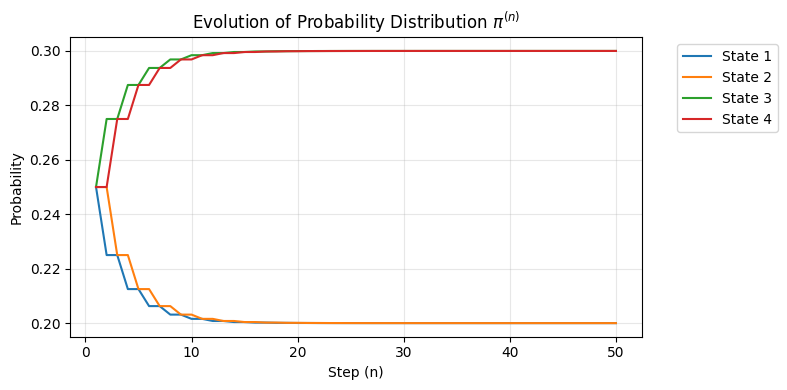

[0.2 0.2 0.3 0.3]


In [ ]:
pi_sup_1 = np.array([0.25, 0.25, 0.25, 0.25])
visualizar_evolucion_marginal(P, pi_sup_1, 50)
print(obtener_marginal(P, pi_sup_1, 50) )

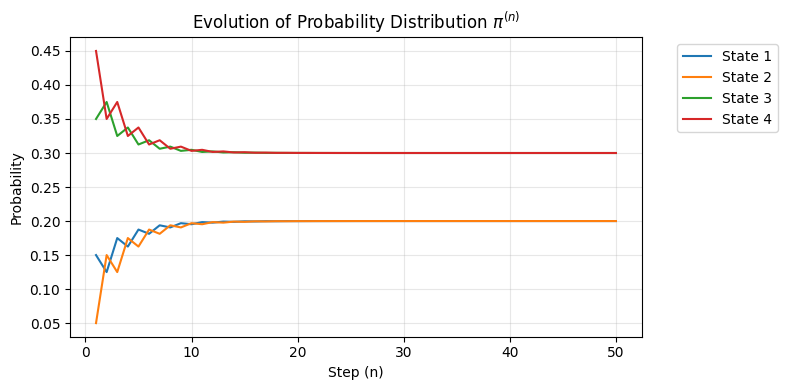

[0.2 0.2 0.3 0.3]


In [ ]:
pi_sup_1 = np.array([0.15, 0.05, 0.35, 0.45])
visualizar_evolucion_marginal(P, pi_sup_1, 50)
print(obtener_marginal(P, pi_sup_1, 50) )

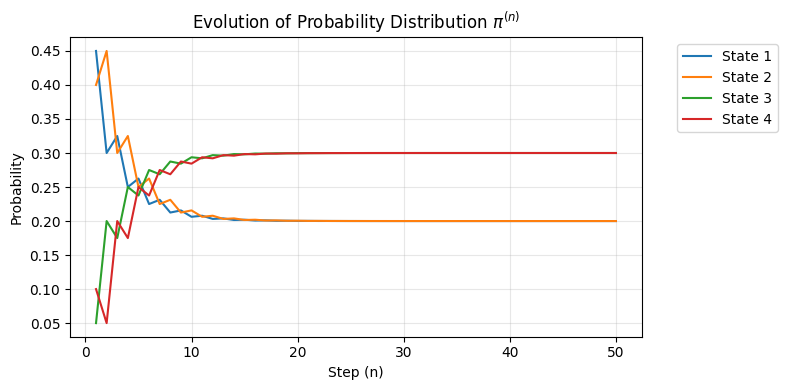

[0.20000001 0.20000001 0.29999999 0.29999999]


In [ ]:
pi_sup_1 = np.array([0.45, 0.40, 0.05, 0.10])
visualizar_evolucion_marginal(P, pi_sup_1, 50)
print(obtener_marginal(P, pi_sup_1, 50) )

Observamos que, en los tres casos, parece producirse convergencia de la marginal a la distribución [0.2 0.2 0.3 0.3]. Efectivamente, se puede demostrar que la MC converge para esas tres condiciones iniciales. ¿Contradice esto el resultado enunciado en la diapositiva 96?

El teorema establece una equivalencia ($\iff$): la marginal de la cadena converge para cualquier distribución inicial si y solo si es aperiódica.

Que converja para algunas distribuciones iniciales en concreto no la hace aperiódica. Para que una cadena no cumpla el teorema, nos basta con encontrar una sola distribución inicial para la cual la marginal no converja, es decir, que se quede oscilando eternamente.

Para mostrar que no lo contradice, proponemos en la siguiente celda una distribución inicial para la que no haya convergencia:

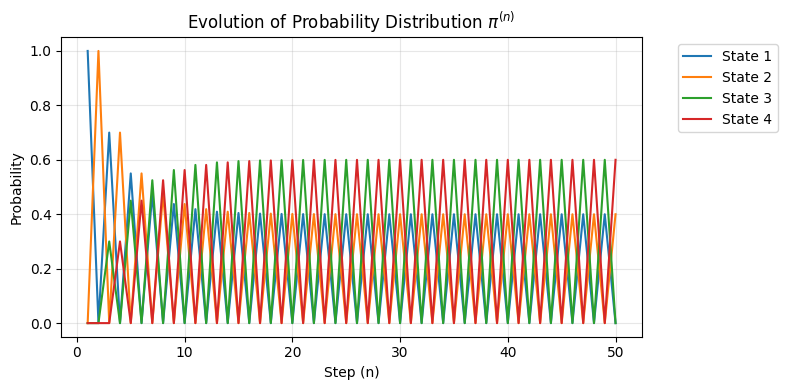

[0.         0.40000004 0.         0.59999996]


In [ ]:
pi_sup_1 = np.array([1.0, 0.0, 0.0, 0.0])
visualizar_evolucion_marginal(P, pi_sup_1, 50)
print(obtener_marginal(P, pi_sup_1, 50) )

Vamos a mirar el tercer y último punto de esta sección. En la siguiente celda, vamos a definir una función que calcula las proporciones $p_i(n_{samples}, n_{steps})$ para una trayectoria aleatoria de una MC dada.

De hecho, dada la MC y dados los valores de $n_{samples}$ y $n_{steps}$, la siguiente función devuelve todas las proporciones $p_i(n_{samples}, n)$ con $i=1,\dots,m$ y $n=1,\dots,n_{steps}$.



In [ ]:
def proporciones_empiricas_hasta_cierto_paso(n_samples, n_steps, P, pi_sup_1):
  """
  Función que obtiene las proporciones empíricas de cada uno de los estados y en cada uno de los pasos, cuando simulamos una cantidad dada de trayectorias.

  Input:

  n_samples: número de trayectorias a simular. Int.
  n_steps: paso hasta el que se quieren calcular las proporciones. Int.
  P: matriz de transición de la MC. Numpy array con shape (m, m), donde m es el número de estados.
  pi_sup_1: distribución inicial de la MC. Numpy array con shape (m,).

  Output:

  props: Proporciones empíricas, es decir, p_i(n_samples, n) para i=1,...,m y n=1,...,n_steps. Array de shape (m, n_steps).
  """

  m = P.shape[0]

  # Paso 1: Utilizamos la función "simular_trayectorias_effic" para simular n_samples trayectorias durante n_steps pasos.
  trayectorias = simular_trayectorias_effic(P, pi_sup_1, n_samples, n_steps)  # (n_samples, n_steps)

  # Paso 2: Comparamos cada item del array anterior con cada uno de los estados i=1,...,m.
  estados = np.arange(1, m + 1).reshape(m, 1, 1)
  is_equal_bool = (trayectorias == estados)   # (m,n_samples,n_steps)

  # Paso 3: Nos fijamos en que las proporciones a devolver (props) no son más que hacer la media en la dimensión de "n_samples" en el array anterior (suponiendo que cada True cuenta como +1 y cada False cuenta como +0).
  props = np.mean(is_equal_bool, axis=1)   # (m,n_steps)

  return props

Utilizamos la función anterior para visualizar la evolución de $p_i(k,k)$ para cada uno de los $i=1,\dots,m$ cuando $k$ crece. Vamos a hacer la visualización para la MC aperiódica y unicadenal que usamos al principio de esta sección. Para ello, rellenamos la siguiente celda:

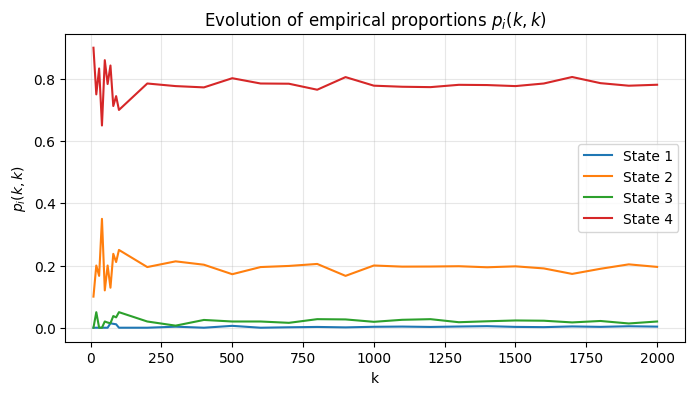

Proporciones empíricas para k=2000:
[0.0035 0.1955 0.02   0.781 ]

Distribución marginal en el paso 50 (teórica límite):
[0.00309598 0.19504644 0.02167183 0.78018576]


In [ ]:
# Definimos la MC (nada que completar aquí)
P = np.array([[0.3,0,0,0.7],
              [0,0.2,0.1,0.7],
              [0.1,0,0.1,0.8],
              [0,0.2,0,0.8]])
pi_sup_1 = np.array([0.25, 0.25, 0.25, 0.25])
m = P.shape[0]

# Definimos el "grid" de valores k que vamos a recorrer
grid = np.concatenate( (np.arange(10, 101, 10),
                        np.arange(200, 2001, 100)) )

# Obtenemos p_i(k,k) para i=1,...,m y para k en el grid anterior.
props_plot = np.zeros((m, len(grid)))
for j in range(len(grid)):
    # Extraemos el valor de k actual
    k = grid[j]

    props_plot[:,j] = proporciones_empiricas_hasta_cierto_paso(k, k, P, pi_sup_1)[:, -1]

# A continuación se hace el gráfico.
plt.figure(figsize=(8, 4))
for i in range(m):
    plt.plot(grid, props_plot[i,:], label=f"State {i+1}")
plt.xlabel("k")
plt.ylabel(r"$p_i(k,k)$")
plt.title(r"Evolution of empirical proportions $p_i(k,k)$")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Mostramos por pantalla dos cosas:
# Primero, las proporciones para el último valor de k, es decir, p_i(2000,2000).
# Segundo, la distribución estacionaria de la MC.
# Según vimos en clase, lo primero debería parecerse a lo segundo para k grande. Y efectivamente vemos que es así.
# No obstante, dependiendo de la ejecución concreta, se parecerá más o menos (una cuestión interesante sería estudiar la velocidad de convergencia, que no parece ser muy elevada porque, para k=2000, aún no parece estabilizarse del todo)
print("Proporciones empíricas para k=2000:")
print(props_plot[:,-1])

print("\nDistribución marginal en el paso 50 (teórica límite):")
print(obtener_marginal(P, pi_sup_1, 50) )

## 5. Teorema ergódico

En esta sección vamos a verificar empíricamente el teorema ergódico para algunas MCs.

Recuerda que el teorema ergódico se enunciaba para una función $f:S\to\mathbb{R}$ arbitraria. Aquí vamos a considerar la función indicadora $f_i$ que se comentó en la diapositiva 107. Por tanto, estaremos calculando lo que denotábamos por $q_i(n)$ en la diapositiva 106. Recuerda que $q_i(n)$ no es más que la frecuencia (o proporción) de visita al estado $i$-ésimo para una trayectoria aleatoria de la MC, es decir:


$$q_i(n) = \frac{\textrm{Cantidad de veces que se visita $i$ en los $n$ primeros pasos}}{n}$$

Como sabemos, se debe cumplir $q_i(n)\geq 0$ y $\sum_i q_i(n) = 1$.  


Vamos a empezar por definir una función que, dada una MC (```P``` y ```pi_sup_1```) y una cantidad de pasos ```n_steps```, calcule las cantidades $q_i(n)$ para cada $i=1,\dots,m$ y cada $n=1,\dots,n_{steps}$. Estos valores los devolverá en un array con shape (m, n_steps).

In [ ]:
def frecuencia_empirica_hasta_cierto_paso(n_steps, P, pi_sup_1):
    """
    Función que calcula la frecuencia empírica de visitas a cada uno de los estados
    para una trayectoria de una MC hasta cierto paso.
    """
    m = P.shape[0]

    # Paso 1: Simular 1 trayectoria para la MC, hasta el paso n_steps
    trayectoria = simular_trayectorias_effic(P, pi_sup_1, 1, n_steps)

    # Paso 2: Comparamos cada valor obtenido con cada uno de los m posibles estados.
    estados = np.arange(1, m + 1).reshape(m, 1)
    is_equal_bool = (trayectoria == estados)

    # Paso 3: Obtenemos el recuento acumulado sumando a lo largo del eje de los pasos
    recuentos_hasta_cierto_paso = np.cumsum(is_equal_bool, axis=1)

    # Paso 4: Dividimos el recuento por el número de paso en el que nos encontramos.
    pasos = np.arange(1, n_steps + 1)
    frecuencias_hasta_cierto_paso = recuentos_hasta_cierto_paso / pasos

    return frecuencias_hasta_cierto_paso

Vamos a usar esta función para visualizar el teorema ergódico en dos MCs que son unicadenales, y por tanto están en las hipótesis del teorema ergódico. Primero miraremos una aperiódica (y que por tanto también está en las condiciones del teorema de convergencia de MCs) y luego miraremos una periódica (y que por tanto NO está en las condiciones del teorema de convergencia de MCs).

Como unicadenal aperiódica tomamos la que hemos usado al principio de la sección 4 anterior:

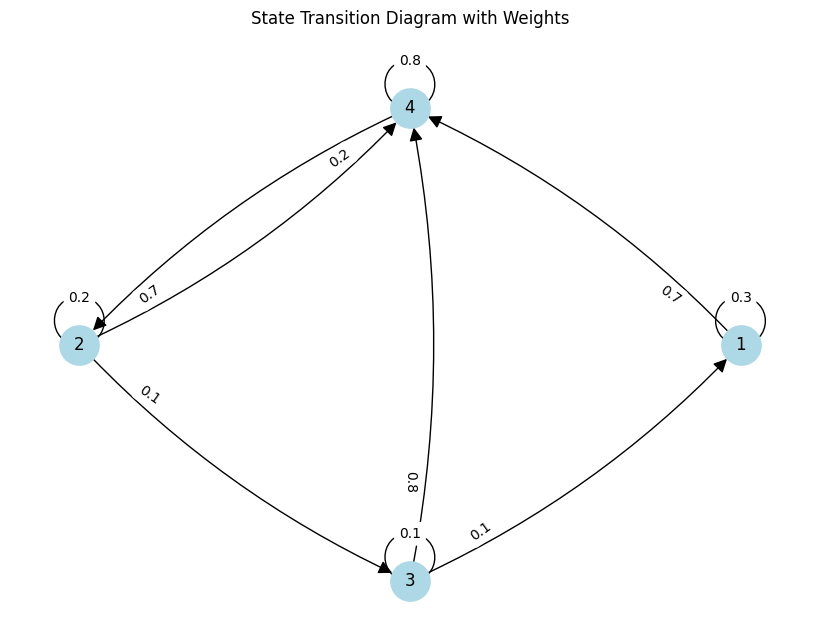

In [ ]:
P = np.array([[0.3,0,0,0.7],
              [0,0.2,0.1,0.7],
              [0.1,0,0.1,0.8],
              [0,0.2,0,0.8]])
dibujar_diagrama_transicion(P, [1,2,3,4])

Recordamos de la sección 4 que la distribución estacionaria de esta MC parecía estar entorno a
$$[0.003, \; 0.195, \; 0.022, \; 0.780]$$
puesto que la marginal se estabilizaba en esos valores. Veamos que, tal y como garantiza el teorema ergódico, las cantidades $q_i(n)$ convergen a la distribución estacionaria, es decir, $q_i(n) \to (\pi)_i$ cuando $n\to\infty$.

En la siguiente celda se representa la evolución de cada una de las $q_i(n)$ cuando $n$ crece (desde $1$ hasta $10000$). Al final del todo también se imprimen por pantalla los valores de $q_i(10000)$, para poder compararlos con la distribución estacionaria.

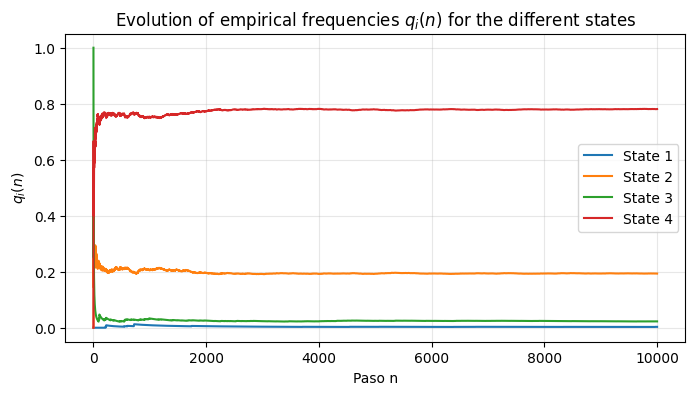

[0.0031 0.1934 0.0226 0.7809]


In [ ]:
P = np.array([[0.3,0,0,0.7],
              [0,0.2,0.1,0.7],
              [0.1,0,0.1,0.8],
              [0,0.2,0,0.8]])
pi_sup_1 = np.array([0.25, 0.25, 0.25, 0.25])

n_steps = 10000
m = P.shape[0]

frecs = frecuencia_empirica_hasta_cierto_paso(n_steps, P, pi_sup_1)  # (m, n_steps)

plt.figure(figsize=(8, 4))
for i in range(m):
  plt.plot(np.arange(1, n_steps+1), frecs[i, :], label=f"State {i+1}")
plt.xlabel("Paso n")
plt.ylabel(r"$q_i(n)$")
plt.title(r"Evolution of empirical frequencies $q_i(n)$ for the different states")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(frecs[:,-1])

Por último, vamos a considerar la MC periódica que vimos en la sección 4:

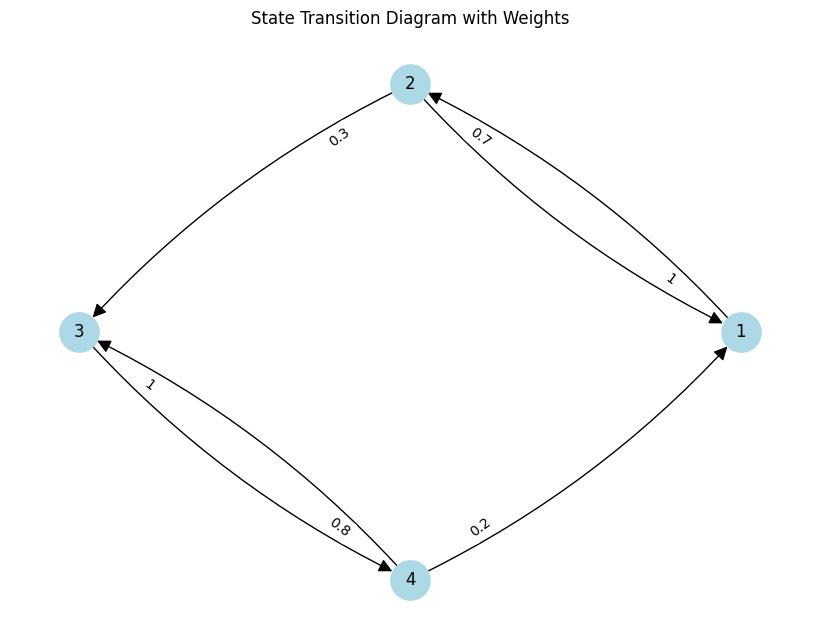

In [ ]:
P = np.array([[0.0,1.0,0.0,0.0],
              [0.7,0.0,0.3,0.0],
              [0.0,0.0,0.0,1.0],
              [0.2,0.0,0.8,0.0]])
dibujar_diagrama_transicion(P, np.arange(1,P.shape[0]+1))

Vamos a seleccionar una distribución inicial ```pi_sup_1``` para la que sabemos que la distribución marginal no converge, como se vio en la sección 4. Y vamos a ver que, aunque la distribución marginal no converge, sí que se cumple el teorema ergódico, y las frecuencias a lo largo de una trayectoria sí que convergen a la distribución estacionaria. En efecto, recuerda que el teorema ergódico no requiere "aperiodicidad" (a diferencia del teorema de convergencia de MCs).

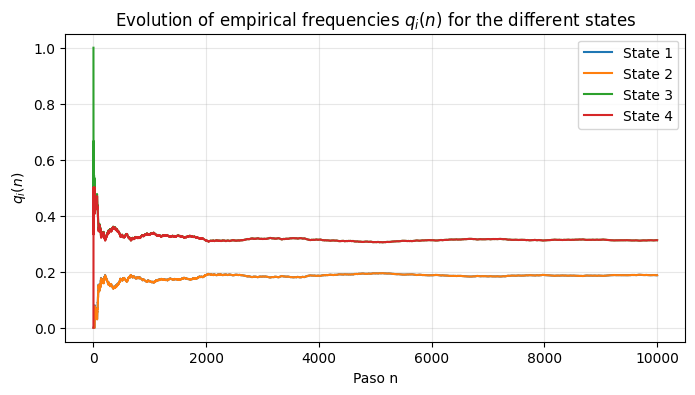

[0.1874 0.1874 0.3126 0.3126]


In [ ]:
P = np.array([[0.0,1.0,0.0,0.0],
              [0.7,0.0,0.3,0.0],
              [0.0,0.0,0.0,1.0],
              [0.2,0.0,0.8,0.0]])
pi_sup_1 = np.array([0.2, 0.3, 0.2, 0.3])

n_steps = 10000
m = P.shape[0]

frecs = frecuencia_empirica_hasta_cierto_paso(n_steps, P, pi_sup_1)  # (m, n_steps)

plt.figure(figsize=(8, 4))
for i in range(m):
  plt.plot(np.arange(1, n_steps+1), frecs[i, :], label=f"State {i+1}")  ## COMPLETAR
plt.xlabel("Paso n")
plt.ylabel(r"$q_i(n)$")
plt.title(r"Evolution of empirical frequencies $q_i(n)$ for the different states")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(frecs[:,-1])

Esto converge al valor esperado. En efecto, recuerda de la sección 4 que la única distribución estacionaria de esta MC venía dada por: [0.2, 0.2, 0.3, 0.3].